<a href="https://colab.research.google.com/github/hmnaz213/native/blob/main/postpaid_data_prep.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task: Consolidate Postpaid Data
The objective is to extract 13 specific Google Sheets from the `postpaid data` directory, harmonize their columns, and merge them into a single, clean, and normalized dataset ready for querying.

## 1. Authentication and Environment Setup

Authenticate the Google Colab environment to access Google Sheets and import required libraries.

In [15]:
import pandas as pd
import gspread
import glob
import os
import re
from google.colab import auth
from google.auth import default

# Authenticate the user
auth.authenticate_user()

# Get credentials and authorize gspread
creds, _ = default()
gc = gspread.authorize(creds)

print("Libraries imported and authentication successful.")

Libraries imported and authentication successful.


## 2. Mount Google Drive

Mount Google Drive to access the `.gsheet` files directly from your specific folder.

In [16]:
from google.colab import drive
drive.mount('/content/drive')
print("Google Drive mounted.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive mounted.


## 3. Verify Target Directory

Locate the specific postpaid data files in the designated path.

In [17]:
# Define the specific target directory
target_dir = '/content/drive/MyDrive/2026/other/ed sa/postpaid data/'

# Find all .gsheet files in this directory
target_files = glob.glob(os.path.join(target_dir, '*.gsheet'))

print(f"Found {len(target_files)} .gsheet files in the target directory.")
if target_files:
    for f in sorted(target_files):
        print(os.path.basename(f))

Found 13 .gsheet files in the target directory.
postpaid april 2026.gsheet
postpaid august 2025.gsheet
postpaid december 2025.gsheet
postpaid february 2026.gsheet
postpaid january 2026.gsheet
postpaid july 2025.gsheet
postpaid june 2025.gsheet
postpaid june 2026.gsheet
postpaid march 2026.gsheet
postpaid may 2026.gsheet
postpaid november 2025.gsheet
postpaid october 2025.gsheet
postpaid september 2025.gsheet


## 4. Extract Data

Iterate over the verified files, extract the temporal feature (month and year) from the filename, and load the data via `gspread`.

In [18]:
dfs = []
date_pattern = r'([A-Za-z]+)\s+(\d{4})'

for filepath in target_files:
    filename = os.path.basename(filepath)
    try:
        # The file title in Drive is usually the filename without .gsheet
        sheet_title = filename.replace('.gsheet', '')

        # Extract temporal feature (Month Year) from filename
        match = re.search(date_pattern, filename, re.IGNORECASE)
        temporal_feature = f"{match.group(1).capitalize()} {match.group(2)}" if match else "Unknown"

        # Open the sheet via gspread using the title
        spreadsheet = gc.open(sheet_title)
        worksheet = spreadsheet.sheet1

        # Use get_all_values() to bypass header duplication errors
        data = worksheet.get_all_values()

        if data and len(data) > 1:
            headers = data[0]
            df = pd.DataFrame(data[1:], columns=headers)
            df['source_file'] = filename
            df['temporal_feature'] = temporal_feature
            dfs.append(df)
            print(f"Loaded: {filename}")

    except Exception as e:
        print(f"Failed to load {filename}: {e}")

print(f"\nTotal DataFrames successfully loaded: {len(dfs)}")

Loaded: postpaid august 2025.gsheet
Loaded: postpaid may 2026.gsheet
Loaded: postpaid april 2026.gsheet
Loaded: postpaid march 2026.gsheet
Loaded: postpaid november 2025.gsheet
Loaded: postpaid september 2025.gsheet
Loaded: postpaid february 2026.gsheet
Loaded: postpaid january 2026.gsheet
Loaded: postpaid july 2025.gsheet
Loaded: postpaid june 2026.gsheet
Loaded: postpaid december 2025.gsheet
Loaded: postpaid june 2025.gsheet
Loaded: postpaid october 2025.gsheet

Total DataFrames successfully loaded: 13


## 5. Harmonize and Combine

Deduplicate column names for each DataFrame to avoid `InvalidIndexError`, concatenate them into a single `combined_df`, and standardize column names.

In [19]:
def make_unique(cols):
    seen = {}
    result = []
    for c in cols:
        c = str(c)
        if c in seen:
            seen[c] += 1
            result.append(f"{c}_{seen[c]}")
        else:
            seen[c] = 0
            result.append(c)
    return result

combined_df = pd.DataFrame()

if dfs:
    for df in dfs:
        df.columns = make_unique(df.columns)

    combined_df = pd.concat(dfs, ignore_index=True)

    # Standardize column names
    combined_df.columns = combined_df.columns.str.lower().str.strip().str.replace(' ', '_')
    print(f"Combined DataFrame constructed successfully.")
else:
    print("No DataFrames were loaded to merge.")

Combined DataFrame constructed successfully.


## 6. Final Results

Display the final dataset shape, info, and a preview.

In [20]:
if not combined_df.empty:
    print(f"Final dataset shape: {combined_df.shape}")
    combined_df.info()
    display(combined_df.head())
else:
    print("Dataset is empty.")

Final dataset shape: (36050, 45)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36050 entries, 0 to 36049
Data columns (total 45 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   no                         24564 non-null  object
 1   region                     33934 non-null  object
 2                              31093 non-null  object
 3   district                   33934 non-null  object
 4   billing_period             33934 non-null  object
 5   from_date                  33934 non-null  object
 6   _1                         31093 non-null  object
 7   to_date                    33934 non-null  object
 8   document#                  33934 non-null  object
 9   customer                   33934 non-null  object
 10  _2                         31093 non-null  object
 11  _3                         31093 non-null  object
 12  account#                   33934 non-null  object
 13  invoice#                   3

,no,region,,district,billing_period,from_date,_1,to_date,document#,customer,...,anomalies,supply_address,_8,pole_number,source_file,temporal_feature,no,govt_acct__in_ouc,govt._acct.,govt._acct._in_ouc
0,1,EASTERN PROVINCE,,41-KENEMA,8-August 2025,2025-08-01,,2025-08-31,UTIL$4410323,CAPITOL FOOD LIMITED,...,Y,"51 HANGA ROAD,9382,-,41-KENEMA",,1000000025,postpaid august 2025.gsheet,August 2025,NaN,NaN,NaN,NaN
1,2,EASTERN PROVINCE,,41-KENEMA,8-August 2025,2025-08-01,,2025-08-31,UTIL$44107877,THE MANAGER BSL,...,N,"2 DAMA ROAD,9383,-,41-KENEMA",,1000000002,postpaid august 2025.gsheet,August 2025,NaN,NaN,NaN,NaN
2,3,EASTERN PROVINCE,,41-KENEMA,8-August 2025,2025-08-01,,2025-08-31,UTIL$44110376,CAPITOL FOODS LIMITED,...,N,"TISSOR VILLAGE,9385,-,41-KENEMA",,1000000002,postpaid august 2025.gsheet,August 2025,NaN,NaN,NaN,NaN
3,4,EASTERN PROVINCE,,41-KENEMA,8-August 2025,2025-08-01,,2025-08-31,PREP$1-41-97778,"SKAIKAY, AMIN",...,Y,",41, 227 HANGA ROAD,6030,STREET,41-KENEMA",,1000000002,postpaid august 2025.gsheet,August 2025,NaN,NaN,NaN,NaN
4,5,EASTERN PROVINCE,,41-KENEMA,8-August 2025,2025-08-01,,2025-08-31,PREP$2-41-01287RR,ROKELCOMMERCIALBANK SL EDSA54320002246,...,N,"41, 12 DAMA RD",,1000000002,postpaid august 2025.gsheet,August 2025,NaN,NaN,NaN,NaN


### 6.1 Data Cleaning: Drop Empty and Unnamed Columns
Remove columns that are artifacts of empty headers (e.g., `_1`, `_2`) or contain entirely empty/null values.

In [27]:
import re
import numpy as np

# 1. Identify and drop columns that are empty strings or match the pattern _1, _2, etc.
unnamed_cols = [col for col in combined_df.columns if str(col).strip() == '' or re.match(r'^_\d+$', str(col))]
print(f"Dropping unnamed/spacer columns: {unnamed_cols}")
combined_df.drop(columns=unnamed_cols, inplace=True)

# 2. Replace empty strings/whitespace with NaN to properly detect entirely empty columns
combined_df.replace(r'^\s*$', np.nan, regex=True, inplace=True)

# 3. Drop columns where ALL values are NaN
combined_df.dropna(axis=1, how='all', inplace=True)

print(f"\nDataset shape after removing empty columns: {combined_df.shape}")
combined_df.info()
display(combined_df.head())

Dropping unnamed/spacer columns: ['', '_1', '_2', '_3', '_4', '_5', '_6', '_7', '_8']


/tmp/ipykernel_685/1219184186.py:10: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  combined_df.replace(r'^\s*$', np.nan, regex=True, inplace=True)



Dataset shape after removing empty columns: (36050, 35)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36050 entries, 0 to 36049
Data columns (total 35 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   no                         24560 non-null  object
 1   region                     33930 non-null  object
 2   district                   33930 non-null  object
 3   billing_period             33930 non-null  object
 4   from_date                  33930 non-null  object
 5   to_date                    33930 non-null  object
 6   document#                  33930 non-null  object
 7   customer                   33930 non-null  object
 8   account#                   33930 non-null  object
 9   invoice#                   33605 non-null  object
 10  bill_#                     33930 non-null  object
 11  generation_date            33930 non-null  object
 12  issue_date                 33930 non-null  object
 13  due_

,no,region,district,billing_period,from_date,to_date,document#,customer,account#,invoice#,...,billed_consumption,anomalies,supply_address,pole_number,source_file,temporal_feature,no,govt_acct__in_ouc,govt._acct.,govt._acct._in_ouc
0,1,EASTERN PROVINCE,41-KENEMA,8-August 2025,2025-08-01,2025-08-31,UTIL$4410323,CAPITOL FOOD LIMITED,1000037610,202508EIN0004392114,...,0,Y,"51 HANGA ROAD,9382,-,41-KENEMA",1000000025,postpaid august 2025.gsheet,August 2025,NaN,NaN,NaN,NaN
1,2,EASTERN PROVINCE,41-KENEMA,8-August 2025,2025-08-01,2025-08-31,UTIL$44107877,THE MANAGER BSL,1000037628,202508EIN0004464573,...,4 943.20,N,"2 DAMA ROAD,9383,-,41-KENEMA",1000000002,postpaid august 2025.gsheet,August 2025,NaN,NaN,NaN,NaN
2,3,EASTERN PROVINCE,41-KENEMA,8-August 2025,2025-08-01,2025-08-31,UTIL$44110376,CAPITOL FOODS LIMITED,1000037644,202508EIN0004464572,...,18 061.60,N,"TISSOR VILLAGE,9385,-,41-KENEMA",1000000002,postpaid august 2025.gsheet,August 2025,NaN,NaN,NaN,NaN
3,4,EASTERN PROVINCE,41-KENEMA,8-August 2025,2025-08-01,2025-08-31,PREP$1-41-97778,"SKAIKAY, AMIN",1000396762,202508EIN0004238650,...,1 621.08,Y,",41, 227 HANGA ROAD,6030,STREET,41-KENEMA",1000000002,postpaid august 2025.gsheet,August 2025,NaN,NaN,NaN,NaN
4,5,EASTERN PROVINCE,41-KENEMA,8-August 2025,2025-08-01,2025-08-31,PREP$2-41-01287RR,ROKELCOMMERCIALBANK SL EDSA54320002246,1002541019,202508EIN0004486376,...,2 444.58,N,"41, 12 DAMA RD",1000000002,postpaid august 2025.gsheet,August 2025,NaN,NaN,NaN,NaN


## 7. Export to CSV
Export the harmonized dataset to a CSV file for future use.

In [28]:
import os

# Define the output path in the same Google Drive directory
output_filename = 'cleaned_combined_postpaid_data.csv'
output_path = os.path.join(target_dir, output_filename)

# Export the cleaned DataFrame to CSV
combined_df.to_csv(output_path, index=False)
print(f"Cleaned data successfully exported to: {output_path}")

Cleaned data successfully exported to: /content/drive/MyDrive/2026/other/ed sa/postpaid data/cleaned_combined_postpaid_data.csv


In [21]:
# Cleaned up

In [22]:
# Cleaned up

In [23]:
# Cleaned up

In [24]:
# Cleaned up

In [25]:
# Cleaned up

## 8. Summary Statistics
Let's generate the summary statistics for the final cleaned DataFrame.

In [29]:
# Generate summary statistics for all columns
display(combined_df.describe(include='all'))

,no,region,district,billing_period,from_date,to_date,document#,customer,account#,invoice#,...,billed_consumption,anomalies,supply_address,pole_number,source_file,temporal_feature,no,govt_acct__in_ouc,govt._acct.,govt._acct._in_ouc
count,24560,33930,33930,33930,33930,33930,33930,33930,33930,33605,...,35896,36046,36046,33919,36050,36050,9370,2841,1966,3933
unique,3390,5,21,13,13,13,3532,3253,3573,33605,...,9130,2,3506,23,13,13,3933,256,230,275
top,1771,WESTERN,82-FREETOWN EAST RURAL,5-May 2026,2026-05-01,2026-05-31,SLDL00493,"KAMARA, MOHAMED",500674748,202510EIN0005741633,...,0,N,"78, 5 GLOUSTER STREET",1000000012,postpaid june 2026.gsheet,June 2026,2596,#N/A,#N/A,#N/A
freq,9,32118,14946,3482,3482,3482,53,118,1029,1,...,17330,23824,52,7620,3933,3933,3,2586,1737,3647


## 9. Data Visualization
Let's visualize the distribution of our records by region using a bar chart.

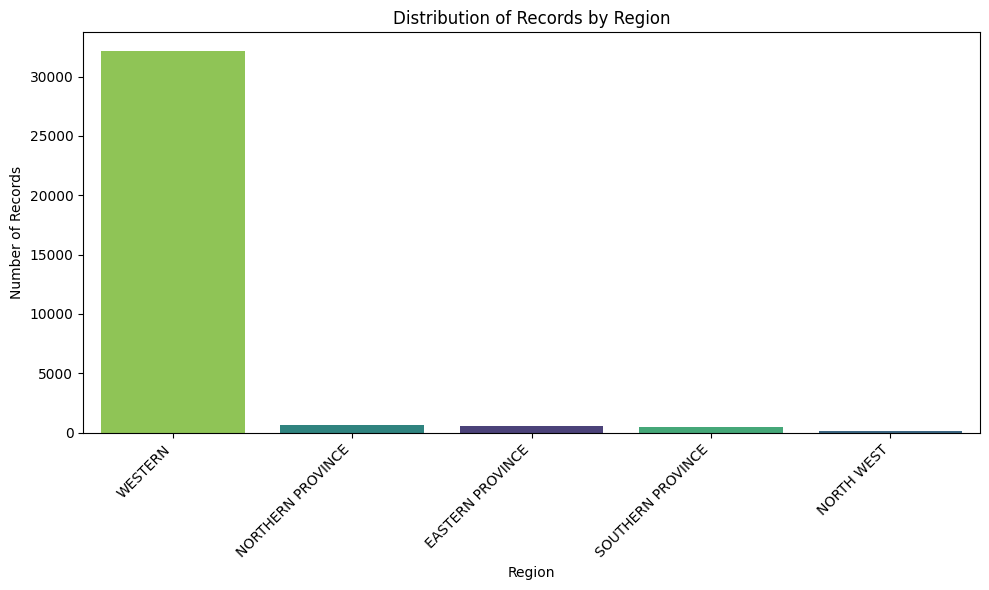

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set figure size
plt.figure(figsize=(10, 6))

# Create a count plot for the 'region' column
sns.countplot(data=combined_df, x='region',
              hue='region',
              order=combined_df['region'].value_counts().index,
              palette='viridis',
              legend=False)

# Add titles and labels
plt.title('Distribution of Records by Region')
plt.xlabel('Region')
plt.ylabel('Number of Records')

# Rotate x-axis labels for better readability
plt.xticks(rotation=45, ha='right')

# Adjust layout and display the plot
plt.tight_layout()
plt.show()

## 10. Document Number Assessment
Let's analyze the `document#` field to check for unique values, duplicates, missing values, and general formatting.

In [32]:
# 1. Basic Summary Statistics
print("--- Basic Summary ---")
display(combined_df['document#'].describe())

# 2. Missing Values
missing_docs = combined_df['document#'].isnull().sum()
print(f"\nMissing/Null Document Numbers: {missing_docs}")

# 3. Top 10 Most Frequent Document Numbers
print("\n--- Top 10 Most Frequent Document Numbers ---")
display(combined_df['document#'].value_counts().head(10))

# 4. Analyze String Lengths (to check for consistent formatting)
print("\n--- Document Number Length Distribution ---")
# Convert to string, ignoring NaNs for length calculation
doc_lengths = combined_df['document#'].dropna().astype(str).str.len()
display(doc_lengths.value_counts().sort_index())

# 5. Check for common prefixes or patterns
print("\n--- Top 5 Common Prefixes (First 4 Characters) ---")
prefixes = combined_df['document#'].dropna().astype(str).str[:4]
display(prefixes.value_counts().head(5))

--- Basic Summary ---


,document#
count,33930
unique,3532
top,SLDL00493
freq,53



Missing/Null Document Numbers: 2120

--- Top 10 Most Frequent Document Numbers ---


,count
document#,
SLDL00493,53
SLDL00509,39
2540736,35
74349278,29
SLDL00486,25
SLDL00833,24
SLDL00528,24
PREP$4-78 -4452,24
SLDL00755,24



--- Document Number Length Distribution ---


,count
document#,
3,32
4,145
5,768
6,141
7,6545
8,3630
9,9389
10,216
11,469



--- Top 5 Common Prefixes (First 4 Characters) ---


,count
document#,
SLDL,9459
UTIL,7209
PREP,4800
1821,1382
AMI$,937


## 11. Customer and Account Number Assessment
Continuing our field-by-field EDA, let's explore the `customer` and `account#` fields to understand user distribution and account formatting.

In [33]:
# --- 1. Customer Field Assessment ---
print("========== CUSTOMER FIELD ==========")
print("--- Basic Summary ---")
display(combined_df['customer'].describe())

missing_customers = combined_df['customer'].isnull().sum()
print(f"\nMissing/Null Customers: {missing_customers}")

print("\n--- Top 10 Most Frequent Customers ---")
display(combined_df['customer'].value_counts().head(10))

print("\n\n========== ACCOUNT# FIELD ==========")
# --- 2. Account# Field Assessment ---
print("--- Basic Summary ---")
display(combined_df['account#'].describe())

missing_accounts = combined_df['account#'].isnull().sum()
print(f"\nMissing/Null Account Numbers: {missing_accounts}")

print("\n--- Top 10 Most Frequent Account Numbers ---")
display(combined_df['account#'].value_counts().head(10))

print("\n--- Account Number Length Distribution ---")
# Convert to string, ignoring NaNs for length calculation
acct_lengths = combined_df['account#'].dropna().astype(str).str.len()
display(acct_lengths.value_counts().sort_index())

========== CUSTOMER FIELD ==========
--- Basic Summary ---


,customer
count,33930
unique,3253
top,"KAMARA, MOHAMED"
freq,118



Missing/Null Customers: 2120

--- Top 10 Most Frequent Customers ---


,count
customer,
"KAMARA, MOHAMED",118
"JALLOH, MOHAMED",94
"SESAY, IBRAHIM",91
"BANGURA, MOHAMED",82
"KAMARA, IBRAHIM",69
MINISTRY OF HEALTH,65
"KAMARA, FODAY",58
SIERRATEL,53
"SESAY, OSMAN",53




========== ACCOUNT# FIELD ==========
--- Basic Summary ---


,account#
count,33930
unique,3573
top,500674748
freq,1029



Missing/Null Account Numbers: 2120

--- Top 10 Most Frequent Account Numbers ---


,count
account#,
500674748,1029
1000044784,14
1000041145,14
500259866,14
500165931,13
1002916748,12
1002984924,12
500113782,12
500113808,12



--- Account Number Length Distribution ---


,count
account#,
9,21264
10,12666


## 12. Billing Period and Status Assessment
Let's analyze the `billing_period`, `billing_status`, and `collection_status` fields to see how the billing cycles are distributed and check the payment/collection states.

In [34]:
print("========== BILLING PERIOD ==========")
# Check the distribution of billing periods
display(combined_df['billing_period'].value_counts())
print(f"\nMissing/Null Billing Periods: {combined_df['billing_period'].isnull().sum()}")

print("\n\n========== BILLING STATUS ==========")
# Check billing status distribution
display(combined_df['billing_status'].value_counts(dropna=False))

print("\n\n========== COLLECTION STATUS ==========")
# Check collection status distribution
display(combined_df['collection_status'].value_counts(dropna=False))

========== BILLING PERIOD ==========


,count
billing_period,
5-May 2026,3482
10-October 2025,3391
6-June 2026,3285
7-July 2025,3199
6-June 2025,3184
8-August 2025,2915
12-December 2025,2778
1-January 2026,2756
2-February 2026,2604



Missing/Null Billing Periods: 2120


========== BILLING STATUS ==========


,count
billing_status,
Invoiced,35618
Generated,325
Invoicing,92
Rebilled,11
NaN,4




========== COLLECTION STATUS ==========


,count
collection_status,
Invoiced,34841
Paid,788
NaN,421


## 13. Financials and Consumption Assessment
Let's convert `total_amount`, `pending_amount`, and `billed_consumption` into numerical data types and analyze their distributions.

In [35]:
# Define the target columns
numeric_cols = ['total_amount', 'pending_amount', 'billed_consumption']

# Clean and convert to numeric
for col in numeric_cols:
    # Remove commas and spaces, then convert to numeric (setting invalid parsing to NaN)
    combined_df[col] = combined_df[col].astype(str).str.replace(',', '', regex=False).str.strip()
    combined_df[col] = pd.to_numeric(combined_df[col], errors='coerce')

print("========== FINANCIALS & CONSUMPTION SUMMARY ==========")
display(combined_df[numeric_cols].describe())

print("\n========== MISSING VALUES ==========")
display(combined_df[numeric_cols].isnull().sum())

========== FINANCIALS & CONSUMPTION SUMMARY ==========


,total_amount,pending_amount,billed_consumption
count,27134.000000,27653.000000,28978.000000
mean,129.770338,126.255672,52.803132
std,190.811801,188.996342,142.147534
min,-981.600000,0.000000,0.000000
25%,13.000000,13.000000,0.000000
50%,13.000000,13.000000,0.000000
75%,202.270000,193.580000,43.000000
max,999.410000,999.410000,999.720000



========== MISSING VALUES ==========


,0
total_amount,8916
pending_amount,8397
billed_consumption,7072


## 14. Date Fields Assessment
Let's analyze the temporal fields: `from_date`, `to_date`, `generation_date`, `issue_date`, and `due_date`. We will convert them to datetime objects to properly assess their ranges.

In [36]:
date_cols = ['from_date', 'to_date', 'generation_date', 'issue_date', 'due_date']

print("========== DATE FIELDS SUMMARY ==========")
for col in date_cols:
    # Convert to datetime, coercing errors to NaT (Not a Time)
    combined_df[col] = pd.to_datetime(combined_df[col], errors='coerce')

    print(f"\n--- {col.upper()} ---")
    print(f"Missing Values: {combined_df[col].isnull().sum()}")
    if not combined_df[col].dropna().empty:
        print(f"Min Date: {combined_df[col].min().date()}")
        print(f"Max Date: {combined_df[col].max().date()}")

========== DATE FIELDS SUMMARY ==========

--- FROM_DATE ---
Missing Values: 2120
Min Date: 2025-06-01
Max Date: 2026-06-01

--- TO_DATE ---
Missing Values: 2120
Min Date: 2025-06-30
Max Date: 2026-06-30

--- GENERATION_DATE ---
Missing Values: 2120
Min Date: 2025-06-09
Max Date: 2026-06-30

--- ISSUE_DATE ---
Missing Values: 2120
Min Date: 2025-06-09
Max Date: 2026-06-30

--- DUE_DATE ---
Missing Values: 2445
Min Date: 2025-06-16
Max Date: 2026-07-14


## 15. Categorical and Service Fields Assessment
Let's examine the distributions of `service`, `contracted_service_status`, `billing_type`, `bill_type`, `tariff`, `vat`, and `anomalies`.

In [37]:
cat_cols = ['service', 'contracted_service_status', 'billing_type', 'bill_type', 'tariff', 'vat', 'anomalies']

print("========== CATEGORICAL FIELDS SUMMARY ==========")
for col in cat_cols:
    print(f"\n--- {col.upper()} ---")
    # Display top 10 most frequent values including NaNs
    display(combined_df[col].value_counts(dropna=False).head(10))

========== CATEGORICAL FIELDS SUMMARY ==========

--- SERVICE ---


,count
service,
Electricity Postpaid,33930
NaN,2120



--- CONTRACTED_SERVICE_STATUS ---


,count
contracted_service_status,
Active,33672
NaN,2131
Pending termination,241
Terminated,6



--- BILLING_TYPE ---


...

,count
tariff,
T1-Residential - Postpayment,25397
T4-MDI – Postpayment-Monthly,9068
T2-Commercial – Postpayment,788
T3-Institutions – Postpayment,419
T4-MDI-Postpayment-Biweekly,293
T1-Residential - Prepayment,40
NaN,18
T7-Welders – Postpayment,11
T5-Street Lighting – Postpayment,9



--- VAT ---


,count
vat,
0,17575
20.89,283
21.52,238
22.15,190
18.99,181
27.85,176
15.19,166
20.26,164
19.62,156



--- ANOMALIES ---


,count
anomalies,
N,23824
Y,12222
NaN,4


## 16. Remaining Text and Geographical Fields
Let's wrap up our field assessment by looking at `tariff`, `anomalies`, `supply_address`, and `pole_number`.

In [38]:
remaining_cols = ['tariff', 'anomalies', 'supply_address', 'pole_number']

print("========== REMAINING FIELDS SUMMARY ==========")
for col in remaining_cols:
    if col in combined_df.columns:
        print(f"\n--- {col.upper()} ---")
        print(f"Missing Values: {combined_df[col].isnull().sum()}")
        display(combined_df[col].value_counts(dropna=False).head(10))
    else:
        print(f"\n--- {col.upper()} --- (Column not found in dataset)")

========== REMAINING FIELDS SUMMARY ==========

--- TARIFF ---
Missing Values: 18


,count
tariff,
T1-Residential - Postpayment,25397
T4-MDI – Postpayment-Monthly,9068
T2-Commercial – Postpayment,788
T3-Institutions – Postpayment,419
T4-MDI-Postpayment-Biweekly,293
T1-Residential - Prepayment,40
NaN,18
T7-Welders – Postpayment,11
T5-Street Lighting – Postpayment,9



--- ANOMALIES ---
Missing Values: 4


,count
anomalies,
N,23824
Y,12222
NaN,4



--- SUPPLY_ADDRESS ---
Missing Values: 4


,count
supply_address,
"78, 5 GLOUSTER STREET",52
"84, TOWER HILL",52
"84, LEICESTER PEAK",44
"81, 198 WILKINSON ROAD",39
"78, 14 WILBERFORCE STREET",39
"78, LOTTO HOUSE OAU DRIVE",39
"80, JOMOKENYATTA ROAD",32
"81, WILKINSON ROAD",26
"FL1,D,14,BRIMA LANE,82-FREETOWN EAST",26



--- POLE_NUMBER ---
Missing Values: 2131


,count
pole_number,
1000000012,7620
1000000013,6507
1000000025,5841
1000000014,4815
1000000016,2161
NaN,2131
1000000019,1750
1000000020,1500
1000000021,654


## 17. Bronze Dataset Creation
We will perform safe structural cleaning without altering the core business values. This includes stripping whitespace, standardizing missing values, and dropping completely empty or duplicated rows.

In [41]:
import numpy as np

print("========== BRONZE DATASET CLEANING ==========")
initial_rows = len(combined_df)

# Deduplicate columns just in case previous lowercasing created duplicates (e.g., 'No' and 'NO' -> 'no')
def make_unique_again(cols):
    seen = {}
    result = []
    for c in cols:
        if c in seen:
            seen[c] += 1
            result.append(f"{c}_{seen[c]}")
        else:
            seen[c] = 0
            result.append(c)
    return result

combined_df.columns = make_unique_again(combined_df.columns)

# 1. Strip whitespace and standardize string 'nan'/empty strings to actual NaN
print("Stripping whitespace and standardizing nulls...")
for col in combined_df.select_dtypes(include=['object']).columns:
    # Only apply string methods to actual strings, avoiding altering non-string data inadvertently
    combined_df[col] = combined_df[col].astype(str).str.strip()
    combined_df[col] = combined_df[col].replace({'': np.nan, 'nan': np.nan, 'None': np.nan})

# 2. Drop rows where ALL core business fields are missing (ignoring our added metadata)
core_cols = [col for col in combined_df.columns if col not in ['source_file', 'temporal_feature']]
combined_df.dropna(subset=core_cols, how='all', inplace=True)
empty_rows_dropped = initial_rows - len(combined_df)
print(f"Dropped {empty_rows_dropped} completely empty business rows.")

# 3. Drop exact duplicate rows
current_rows = len(combined_df)
combined_df.drop_duplicates(inplace=True)
dupes_dropped = current_rows - len(combined_df)
print(f"Dropped {dupes_dropped} exact duplicate rows.")

print("\n--- Bronze Dataset Status ---")
print(f"Final Bronze Shape: {combined_df.shape}")
combined_df.info()

========== BRONZE DATASET CLEANING ==========
Stripping whitespace and standardizing nulls...
Dropped 2 completely empty business rows.
Dropped 11 exact duplicate rows.

--- Bronze Dataset Status ---
Final Bronze Shape: (36037, 35)
<class 'pandas.core.frame.DataFrame'>
Index: 36037 entries, 0 to 36049
Data columns (total 35 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   no                         24560 non-null  object        
 1   region                     33930 non-null  object        
 2   district                   33930 non-null  object        
 3   billing_period             33930 non-null  object        
 4   from_date                  33930 non-null  datetime64[ns]
 5   to_date                    33930 non-null  datetime64[ns]
 6   document#                  33930 non-null  object        
 7   customer                   33930 non-null  object        
 8   account#                   33

In [40]:
# Export the formalized Bronze Dataset
bronze_output_filename = 'bronze_postpaid_data.csv'
bronze_output_path = os.path.join(target_dir, bronze_output_filename)

combined_df.to_csv(bronze_output_path, index=False)
print(f"Bronze dataset successfully exported to: {bronze_output_path}")

Bronze dataset successfully exported to: /content/drive/MyDrive/2026/other/ed sa/postpaid data/bronze_postpaid_data.csv


## 18. Pipeline Transformation Summary
Let's visualize how our dataset transformed from the initial raw merge to our finalized Bronze state.

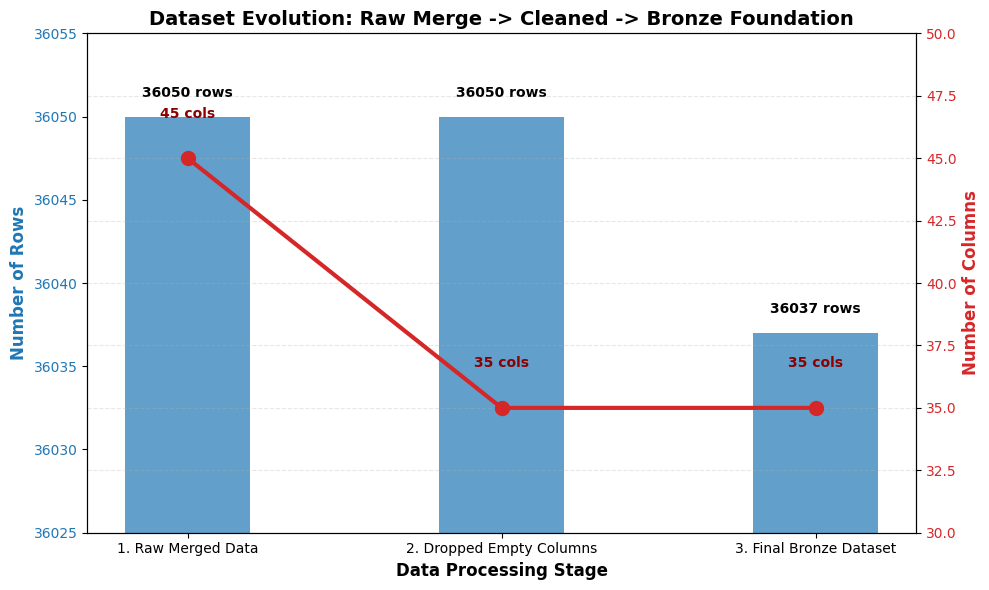

In [42]:
import matplotlib.pyplot as plt

# Data points representing the evolution of our dataset
stages = ['1. Raw Merged Data', '2. Dropped Empty Columns', '3. Final Bronze Dataset']
rows = [36050, 36050, 36037]
cols = [45, 35, 35]

fig, ax1 = plt.subplots(figsize=(10, 6))

# Bar chart for rows (Secondary Y-axis to zoom in on the small change)
color = 'tab:blue'
ax1.set_xlabel('Data Processing Stage', fontweight='bold', fontsize=12)
ax1.set_ylabel('Number of Rows', color=color, fontweight='bold', fontsize=12)
bars = ax1.bar(stages, rows, color=color, alpha=0.7, width=0.4)
ax1.tick_params(axis='y', labelcolor=color)
# Zoom the Y-axis heavily to show the drop of 13 rows
ax1.set_ylim(36025, 36055)

# Line chart for columns (Primary Y-axis)
ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Number of Columns', color=color, fontweight='bold', fontsize=12)
line = ax2.plot(stages, cols, color=color, marker='o', linewidth=3, markersize=10)
ax2.tick_params(axis='y', labelcolor=color)
ax2.set_ylim(30, 50)

# Add text annotations for rows
for bar in bars:
    yval = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, yval + 1, f'{yval} rows', ha='center', va='bottom', color='black', fontweight='bold')

# Add text annotations for columns
for i, txt in enumerate(cols):
    ax2.text(i, txt + 1.5, f'{txt} cols', ha='center', va='bottom', color='darkred', fontweight='bold')

plt.title('Dataset Evolution: Raw Merge -> Cleaned -> Bronze Foundation', fontweight='bold', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.3)
fig.tight_layout()
plt.show()

## 19. Silver Dataset: Date Standardization & Dropping Sparse Columns
Let's fix the inconsistent date formats (specifically cleaning `billing_period`) and remove the highly sparse `govt` columns that are cluttering the dataset.

In [43]:
# 1. Standardize 'billing_period'
print("--- Standardizing Dates ---")
# Remove prefixes like '8-' from '8-August 2025'
combined_df['billing_period'] = combined_df['billing_period'].astype(str).str.replace(r'^\d+-', '', regex=True)

# Convert to a standard YYYY-MM format
combined_df['billing_period'] = pd.to_datetime(combined_df['billing_period'], errors='coerce').dt.strftime('%Y-%m')

# Standardize all other date columns to YYYY-MM-DD format
date_cols = ['from_date', 'to_date', 'generation_date', 'issue_date', 'due_date']
for col in date_cols:
    combined_df[col] = pd.to_datetime(combined_df[col], errors='coerce').dt.strftime('%Y-%m-%d')

display(combined_df[['billing_period'] + date_cols].head())


--- Standardizing Dates ---


/tmp/ipykernel_685/2921532586.py:7: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  combined_df['billing_period'] = pd.to_datetime(combined_df['billing_period'], errors='coerce').dt.strftime('%Y-%m')


,billing_period,from_date,to_date,generation_date,issue_date,due_date
0,2025-08,2025-08-01,2025-08-31,2025-08-26,2025-08-26,2025-08-29
1,2025-08,2025-08-01,2025-08-31,2025-08-16,2025-08-30,2025-09-02
2,2025-08,2025-08-01,2025-08-31,2025-08-15,2025-08-30,2025-09-02
3,2025-08,2025-08-01,2025-08-31,2025-08-18,2025-08-18,2025-09-01
4,2025-08,2025-08-01,2025-08-31,2025-08-15,2025-08-31,2025-09-15


In [44]:
# 2. Handle 'govt' columns
print("\n--- Assessing 'govt' columns ---")
govt_cols = [col for col in combined_df.columns if 'govt' in col.lower()]
print(f"Found 'govt' columns: {govt_cols}")

# Check how much data is actually missing in these columns
for col in govt_cols:
    missing_pct = combined_df[col].isnull().mean() * 100
    print(f"{col}: {missing_pct:.2f}% missing")

# Drop them since they are almost entirely empty and not part of the core schema
print("\nDropping 'govt' columns to harmonize the dataset...")
combined_df.drop(columns=govt_cols, inplace=True)

print(f"Dataset shape is now: {combined_df.shape}")
display(combined_df.head())



--- Assessing 'govt' columns ---
Found 'govt' columns: ['govt_acct__in_ouc', 'govt._acct.', 'govt._acct._in_ouc']
govt_acct__in_ouc: 92.12% missing
govt._acct.: 94.54% missing
govt._acct._in_ouc: 89.09% missing

Dropping 'govt' columns to harmonize the dataset...
Dataset shape is now: (36037, 32)


,no,region,district,billing_period,from_date,to_date,document#,customer,account#,invoice#,...,itinerary,total_amount,pending_amount,billed_consumption,anomalies,supply_address,pole_number,source_file,temporal_feature,no_1
0,1,EASTERN PROVINCE,41-KENEMA,2025-08,2025-08-01,2025-08-31,UTIL$4410323,CAPITOL FOOD LIMITED,1000037610,202508EIN0004392114,...,3301 KENEMA-00001,310.4,310.4,0.0,Y,"51 HANGA ROAD,9382,-,41-KENEMA",1000000025,postpaid august 2025.gsheet,August 2025,NaN
1,2,EASTERN PROVINCE,41-KENEMA,2025-08,2025-08-01,2025-08-31,UTIL$44107877,THE MANAGER BSL,1000037628,202508EIN0004464573,...,4004-AMRMDI FREETO-00001,NaN,NaN,NaN,N,"2 DAMA ROAD,9383,-,41-KENEMA",1000000002,postpaid august 2025.gsheet,August 2025,NaN
2,3,EASTERN PROVINCE,41-KENEMA,2025-08,2025-08-01,2025-08-31,UTIL$44110376,CAPITOL FOODS LIMITED,1000037644,202508EIN0004464572,...,4004-AMRMDI FREETO-00001,NaN,NaN,NaN,N,"TISSOR VILLAGE,9385,-,41-KENEMA",1000000002,postpaid august 2025.gsheet,August 2025,NaN
3,4,EASTERN PROVINCE,41-KENEMA,2025-08,2025-08-01,2025-08-31,PREP$1-41-97778,"SKAIKAY, AMIN",1000396762,202508EIN0004238650,...,4004-AMRMDI FREETO-00001,NaN,NaN,NaN,Y,",41, 227 HANGA ROAD,6030,STREET,41-KENEMA",1000000002,postpaid august 2025.gsheet,August 2025,NaN
4,5,EASTERN PROVINCE,41-KENEMA,2025-08,2025-08-01,2025-08-31,PREP$2-41-01287RR,ROKELCOMMERCIALBANK SL EDSA54320002246,1002541019,202508EIN0004486376,...,4004-AMRMDI FREETO-00001,NaN,NaN,NaN,N,"41, 12 DAMA RD",1000000002,postpaid august 2025.gsheet,August 2025,NaN


## 20. Deep Dive: Financial & Categorical Anomalies
Let's investigate potential data quality issues in our numeric fields (zeros, negatives, missing values) and check for text inconsistencies in our categorical fields.

In [45]:
print("--- 1. Financial & Consumption Deep Dive ---")
numeric_cols = ['total_amount', 'pending_amount', 'billed_consumption']

for col in numeric_cols:
    missing = combined_df[col].isna().sum()
    zeros = (combined_df[col] == 0).sum()
    negatives = (combined_df[col] < 0).sum()

    print(f"\n[{col.upper()}]")
    print(f"  - Missing (NaN): {missing} ({(missing/len(combined_df))*100:.1f}%)")
    print(f"  - Exactly Zero:  {zeros} ({(zeros/len(combined_df))*100:.1f}%)")
    print(f"  - Negative (<0): {negatives} ({(negatives/len(combined_df))*100:.1f}%)")

# Let's peek at some negative amounts if they exist
if (combined_df['total_amount'] < 0).any():
    print("\nSample of Negative Total Amounts:")
    display(combined_df[combined_df['total_amount'] < 0][['document#', 'total_amount', 'pending_amount', 'billing_status']].head())


--- 1. Financial & Consumption Deep Dive ---

[TOTAL_AMOUNT]
  - Missing (NaN): 8914 (24.7%)
  - Exactly Zero:  0 (0.0%)
  - Negative (<0): 2 (0.0%)

[PENDING_AMOUNT]
  - Missing (NaN): 8395 (23.3%)
  - Exactly Zero:  789 (2.2%)
  - Negative (<0): 0 (0.0%)

[BILLED_CONSUMPTION]
  - Missing (NaN): 7070 (19.6%)
  - Exactly Zero:  17319 (48.1%)
  - Negative (<0): 0 (0.0%)

Sample of Negative Total Amounts:


,document#,total_amount,pending_amount,billing_status
2979,PREP$1-41-075754,-981.6,0.0,Invoiced
2981,PREP$1-41-10897,-981.6,0.0,Invoiced


In [46]:
print("\n--- 2. Categorical Consistency Deep Dive ---")
cat_check_cols = ['region', 'district', 'contracted_service_status', 'billing_status']

for col in cat_check_cols:
    print(f"\n[{col.upper()}] Unique Values:")
    # Dropna to focus on the actual strings, then get value counts
    val_counts = combined_df[col].dropna().value_counts()
    print(val_counts.to_string())

    # Flag if there are suspicious lower/uppercase overlaps
    unique_lower = set(val.lower() for val in val_counts.index.astype(str))
    if len(unique_lower) < len(val_counts):
        print(f"  ⚠️ WARNING: Possible casing inconsistency detected in {col}!")



--- 2. Categorical Consistency Deep Dive ---

[REGION] Unique Values:
region
WESTERN              32118
NORTHERN PROVINCE      649
EASTERN PROVINCE       527
SOUTHERN PROVINCE      471
NORTH WEST             165

[DISTRICT] Unique Values:
district
82-FREETOWN EAST RURAL    14946
83-FREETOWN EAST           7029
80-FREETOWN WEST           2143
84-FREETOWN WEST RURAL     2124
81-FREETOWN WEST           1158
78-FREETOWN CENTRAL        1008
77-FREETOWN CENTRAL         683
70-FREETOWN CENTRAL         650
75-FREETOWN CENTRAL         602
79-FREETOWN CENTRAL         569
51-BOMBALI                  505
72-FREETOWN CENTRAL         497
31-BO                       471
41-KENEMA                   414
76-FREETOWN CENTRAL         225
74-FREETOWN CENTRAL         176
50-PORT LOKO                165
71-FREETOWN CENTRAL         155
73-FREETOWN CENTRAL         153
54-TONKOLILI                144
48-KONO                     113

[CONTRACTED_SERVICE_STATUS] Unique Values:
contracted_service_status
Active   

## 21. Silver Dataset Export
We have completed our "Silver" transformations (date standardization, dropping sparse columns, text formatting check, and retaining financial `NaN`s for data integrity). Let's export this analytical-ready dataset.

In [47]:
# Export the finalized Silver Dataset
silver_output_filename = 'silver_postpaid_data.csv'
silver_output_path = os.path.join(target_dir, silver_output_filename)

combined_df.to_csv(silver_output_path, index=False)
print(f"Silver dataset successfully exported to: {silver_output_path}")

# Final shape check
print(f"Final Silver Shape: {combined_df.shape}")

Silver dataset successfully exported to: /content/drive/MyDrive/2026/other/ed sa/postpaid data/silver_postpaid_data.csv
Final Silver Shape: (36037, 32)


## 22. Revised EDA Report & Methodology

### The Logic Behind Our EDA Process
Our Exploratory Data Analysis (EDA) and data engineering process followed a structured Medallion Architecture (Raw -> Bronze -> Silver) to ensure data integrity:

1. **Ingestion & Consolidation (Raw):**
   - We dynamically loaded 13 disjointed Google Sheets.
   - **Logic:** Harmonizing column headers was necessary because the sheets had duplicate/unnamed columns that would break standard pandas joins.
2. **Structural Cleaning (Bronze):**
   - Dropped purely empty rows and exact duplicates.
   - Stripped whitespace and standardized `NaN` values across text fields.
   - **Logic:** Before analyzing data, we must remove structural artifacts (like spacer columns `_1`, `_2`) to get an accurate row/column count of true business data.
3. **Semantic Cleaning & Formatting (Silver):**
   - Standardized `billing_period` to `YYYY-MM` and converted dates to `YYYY-MM-DD`.
   - Dropped highly sparse columns (e.g., `govt_acct__in_ouc` which were ~90%+ empty).
   - **Logic (Handling Financials):** We intentionally kept `NaN` values in `total_amount`, `pending_amount`, and `billed_consumption`. Filling these with `0` or `mean` averages would distort actual revenue calculations and mask underlying system issues (e.g., missing generation data).
4. **Deep Dive Profiling:**
   - Checked categorical fields for casing overlaps (e.g., making sure 'WESTERN' isn't split with 'Western').
   - Assessed numerical boundaries (identifying negative billings and exact zeros).

Below are the revised visualizations based on our cleaned **Silver Dataset**.

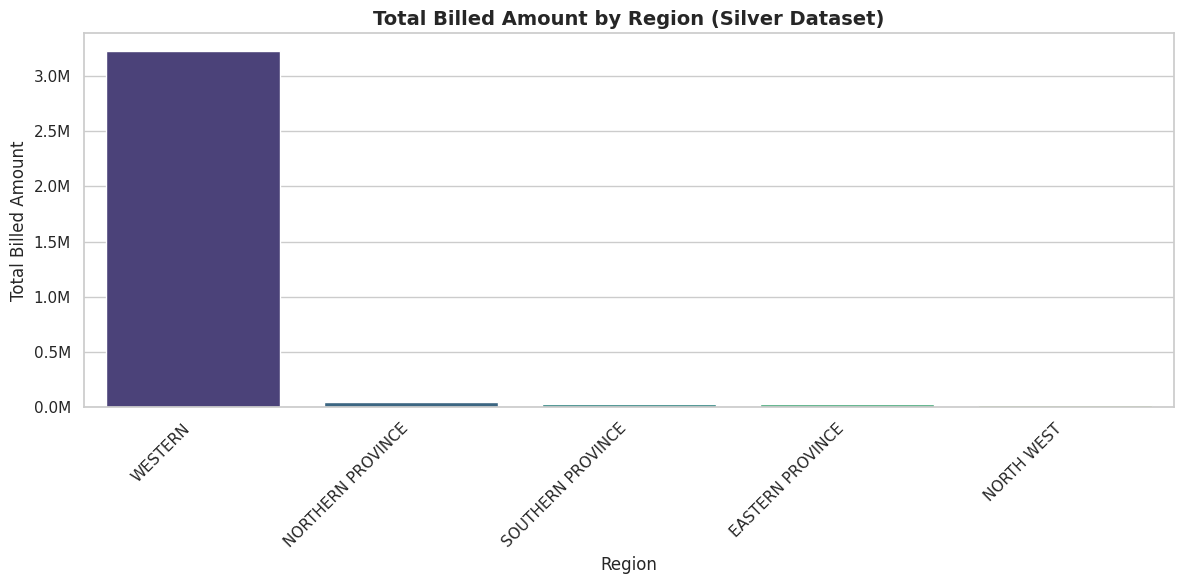

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

# Set general style
sns.set_theme(style="whitegrid")

# 1. Financial Overview: Total Amount by Region
# Grouping by region and summing the total amount (ignoring NaNs automatically)
region_revenue = combined_df.groupby('region')['total_amount'].sum().sort_values(ascending=False).reset_index()

plt.figure(figsize=(12, 6))
ax = sns.barplot(data=region_revenue, x='region', y='total_amount', hue='region', palette='viridis', legend=False)
plt.title('Total Billed Amount by Region (Silver Dataset)', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Total Billed Amount')
plt.xlabel('Region')

# Format Y-axis to show millions cleanly
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x/1e6:,.1f}M'))
plt.tight_layout()
plt.show()

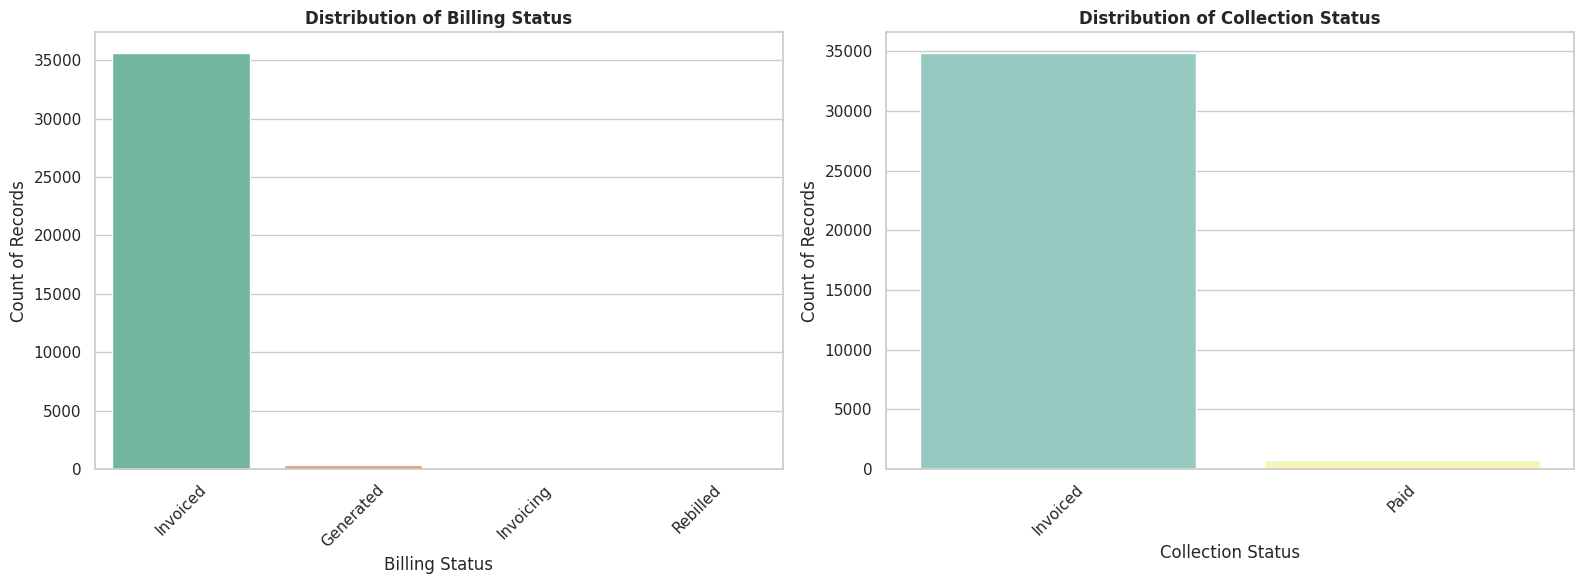

In [51]:
# 2. Operational Overview: Billing and Collection Status Distributions
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Billing Status
sns.countplot(data=combined_df, x='billing_status', hue='billing_status', ax=axes[0], palette='Set2',
              order=combined_df['billing_status'].value_counts().index, legend=False)
axes[0].set_title('Distribution of Billing Status', fontsize=12, fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)
axes[0].set_ylabel('Count of Records')
axes[0].set_xlabel('Billing Status')

# Collection Status
sns.countplot(data=combined_df, x='collection_status', hue='collection_status', ax=axes[1], palette='Set3',
              order=combined_df['collection_status'].value_counts().index, legend=False)
axes[1].set_title('Distribution of Collection Status', fontsize=12, fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)
axes[1].set_ylabel('Count of Records')
axes[1].set_xlabel('Collection Status')

plt.tight_layout()
plt.show()

## 23. Gold Layer: Frequency Distributions
Let's explore the geographic distribution of our records. We will visualize the frequency of records at both the broader **Region** level and the more granular **District** level.

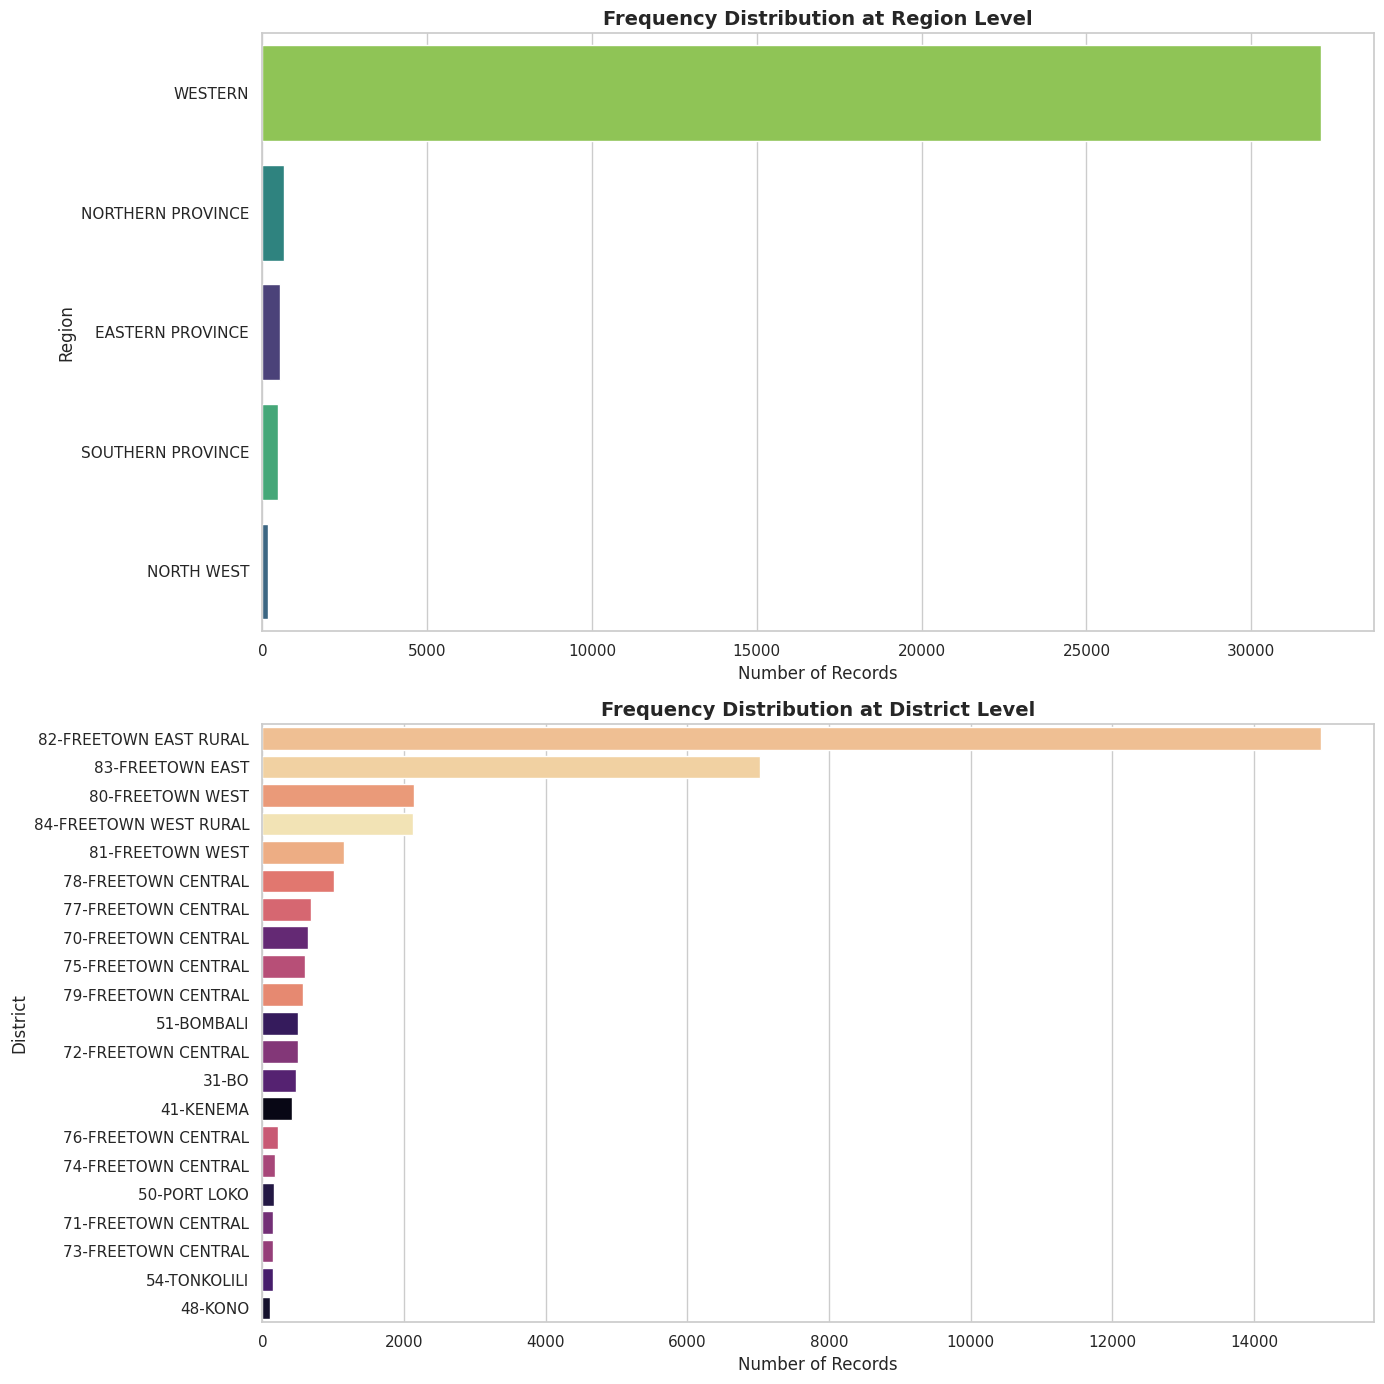

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the figure size to accommodate both charts comfortably
fig, axes = plt.subplots(2, 1, figsize=(14, 14))
sns.set_theme(style="whitegrid")

# 1. Frequency Distribution at the Region Level
sns.countplot(data=combined_df, y='region', hue='region', ax=axes[0], palette='viridis',
              order=combined_df['region'].value_counts().index, legend=False)
axes[0].set_title('Frequency Distribution at Region Level', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Number of Records', fontsize=12)
axes[0].set_ylabel('Region', fontsize=12)

# 2. Frequency Distribution at the District Level
sns.countplot(data=combined_df, y='district', hue='district', ax=axes[1], palette='magma',
              order=combined_df['district'].value_counts().index, legend=False)
axes[1].set_title('Frequency Distribution at District Level', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Number of Records', fontsize=12)
axes[1].set_ylabel('District', fontsize=12)

# Adjust layout to prevent overlapping
plt.tight_layout()
plt.show()